In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
torch.manual_seed(42)

In [3]:
iris = load_iris()
X = iris.data               # shape (150, 4)
y = iris.target             # shape (150,)

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# Standardize features
scaler      = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std  = scaler.transform(X_test)

# Convert to torch tensors
X_train_t = torch.tensor(X_train_std, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_std,  dtype=torch.float32)
y_train_t = torch.tensor(y_train,     dtype=torch.long)
y_test_t  = torch.tensor(y_test,      dtype=torch.long)

### 2.2 NumPy MLP Forward & Backward

In [4]:
def one_hot(y, num_classes=3):
    Y = np.zeros((y.size, num_classes))
    Y[np.arange(y.size), y] = 1
    return Y

Y_train_oh = one_hot(y_train, num_classes=3)

In [5]:
input_dim, hidden_dim1, hidden_dim2, output_dim = 4, 10, 10, 3
lr_np       = 10
epochs_np   = 500

# Initialize parameters
rng = np.random.RandomState(42)
W1 = rng.randn(input_dim, hidden_dim1) * 0.01
b1 = np.zeros((1, hidden_dim1))
W2 = rng.randn(hidden_dim1, hidden_dim2) * 0.01
b2 = np.zeros((1, hidden_dim2))
W3 = rng.randn(hidden_dim2, output_dim) * 0.01
b3 = np.zeros((1, output_dim))

In [ ]:
# Activation / loss / grads
def sigmoid(x):
    # TODO: implement the sigmoid activation
    return 1 / 1 + np.exp(-x)

def sigmoid_grad(x):
    # TODO: implement the derivative of sigmoid
    return sigmoid(x) * (1 - sigmoid(x))

def softmax(x):
    # TODO: implement softmax over each row
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

def cross_entropy_loss(Y_true, P_pred):
    """
    Y_true: one‑hot labels, shape (N, C)
    P_pred: softmax probabilities, shape (N, C)
    """
    # TODO: compute average cross‑entropy loss
    return -np.sum(np.log(P_pred) * Y_true, axis=1)


def compute_loss_and_grads(Xb, Yb, W1, b1, W2, b2, W3, b3):
    N = Xb.shape[0]

    # TODO: forward pass (sigmoid layers + softmax output)


    # TODO: compute loss

    # TODO: backward pass to compute dW3, db3, dW2, db2, dW1, db1


    return loss, dW1, db1, dW2, db2, dW3, db3

i = 0
loss_np, dW1_np, db1_np, dW2_np, db2_np, dW3_np, db3_np = compute_loss_and_grads(
    X_train_std[i:i+1], y_train[i:i+1] , W1, b1, W2, b2, W3, b3
)

print("NumPy gradient shapes:",
      "\ndW1:", dW1_np.shape,
      "\ndb1:", db1_np.shape,
      "\ndW2:", dW2_np.shape,
      "\ndb2:", db2_np.shape,
      "\ndW3:", dW3_np.shape,
      "\ndb3:", db3_np.shape)

NumPy gradient shapes: 
dW1: (4, 10) 
db1: (1, 10) 
dW2: (10, 10) 
db2: (1, 10) 
dW3: (10, 3) 
db3: (1, 3)


In [ ]:
loss_hist_np = []
for epoch in range(epochs_np):

    # TODO: call compute_loss_and_grads on the full batch


    # TODO: update parameters W1, b1, W2, b2, W3, b3 using gradients and lr_np

    if (epoch+1) % 10 == 1:
        print(f"[NumPy] Epoch {epoch+1}/{epochs_np}, Loss: {loss_np:.6f}")


[NumPy] Epoch 1/500, Loss: 1.098720
[NumPy] Epoch 11/500, Loss: 0.961773
[NumPy] Epoch 21/500, Loss: 1.053501
[NumPy] Epoch 31/500, Loss: 1.034728
[NumPy] Epoch 41/500, Loss: 1.029106
[NumPy] Epoch 51/500, Loss: 1.026321
[NumPy] Epoch 61/500, Loss: 1.024683
[NumPy] Epoch 71/500, Loss: 1.023612
[NumPy] Epoch 81/500, Loss: 1.022863
[NumPy] Epoch 91/500, Loss: 1.022311
[NumPy] Epoch 101/500, Loss: 1.021888
[NumPy] Epoch 111/500, Loss: 1.021556
[NumPy] Epoch 121/500, Loss: 1.021287
[NumPy] Epoch 131/500, Loss: 1.021067
[NumPy] Epoch 141/500, Loss: 1.020883
[NumPy] Epoch 151/500, Loss: 1.020727
[NumPy] Epoch 161/500, Loss: 1.020593
[NumPy] Epoch 171/500, Loss: 1.020477
[NumPy] Epoch 181/500, Loss: 1.020376
[NumPy] Epoch 191/500, Loss: 1.020287
[NumPy] Epoch 201/500, Loss: 1.020208
[NumPy] Epoch 211/500, Loss: 1.020137
[NumPy] Epoch 221/500, Loss: 1.020074
[NumPy] Epoch 231/500, Loss: 1.020017
[NumPy] Epoch 241/500, Loss: 1.019965
[NumPy] Epoch 251/500, Loss: 1.019918
[NumPy] Epoch 261/500, 

In [33]:
# Evaluate NumPy model

# TODO: forward pass on X_test_std to compute preds_np
acc_np   = np.mean(preds_np == y_test)
print(f"\n[NumPy] Test Accuracy: {acc_np:.4f}\n")


[NumPy] Test Accuracy: 0.6316



### PyTorch MLP with Sigmoid + CrossEntropyLoss

In [ ]:
class IrisNet(nn.Module):
    def __init__(self, input_dim=4, h1=10, h2=10, out_dim=3):
        super().__init__()
        # TODO: define self.fc1, self.act1, self.fc2, self.act2, self.fc3
        pass

    def forward(self, x):
        # TODO: implement forward using nn.Sigmoid activations
        pass


In [ ]:
# TODO: instantiate model, criterion, optimizer

epochs_pt = 500
loss_hist_pt = []

for epoch in range(epochs_pt):

    # TODO: standard PyTorch training loop

    if (epoch+1) % 10 == 0:
        print(f"[PyTorch] Epoch {epoch+1}/{epochs_pt}, Loss: {loss.item():.4f}")


[PyTorch] Epoch 10/500, Loss: 1.1085
[PyTorch] Epoch 20/500, Loss: 1.1007
[PyTorch] Epoch 30/500, Loss: 1.0987
[PyTorch] Epoch 40/500, Loss: 1.0972
[PyTorch] Epoch 50/500, Loss: 1.0958
[PyTorch] Epoch 60/500, Loss: 1.0943
[PyTorch] Epoch 70/500, Loss: 1.0927
[PyTorch] Epoch 80/500, Loss: 1.0909
[PyTorch] Epoch 90/500, Loss: 1.0890
[PyTorch] Epoch 100/500, Loss: 1.0868
[PyTorch] Epoch 110/500, Loss: 1.0844
[PyTorch] Epoch 120/500, Loss: 1.0818
[PyTorch] Epoch 130/500, Loss: 1.0787
[PyTorch] Epoch 140/500, Loss: 1.0753
[PyTorch] Epoch 150/500, Loss: 1.0714
[PyTorch] Epoch 160/500, Loss: 1.0669
[PyTorch] Epoch 170/500, Loss: 1.0619
[PyTorch] Epoch 180/500, Loss: 1.0561
[PyTorch] Epoch 190/500, Loss: 1.0494
[PyTorch] Epoch 200/500, Loss: 1.0418
[PyTorch] Epoch 210/500, Loss: 1.0330
[PyTorch] Epoch 220/500, Loss: 1.0229
[PyTorch] Epoch 230/500, Loss: 1.0115
[PyTorch] Epoch 240/500, Loss: 0.9984
[PyTorch] Epoch 250/500, Loss: 0.9835
[PyTorch] Epoch 260/500, Loss: 0.9668
[PyTorch] Epoch 270/5

### Evaluate PyTorch model

In [ ]:
# TODO: compute preds_pt and accuracy

print(f"\n[PyTorch] Test Accuracy: {acc_pt:.4f}\n")
print("Classification Report (PyTorch):")
print(classification_report(y_test, preds_pt, target_names=iris.target_names))



[PyTorch] Test Accuracy: 0.8684

Classification Report (PyTorch):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.90      0.69      0.78        13
   virginica       0.75      0.92      0.83        13

    accuracy                           0.87        38
   macro avg       0.88      0.87      0.87        38
weighted avg       0.88      0.87      0.87        38



### Visualizations

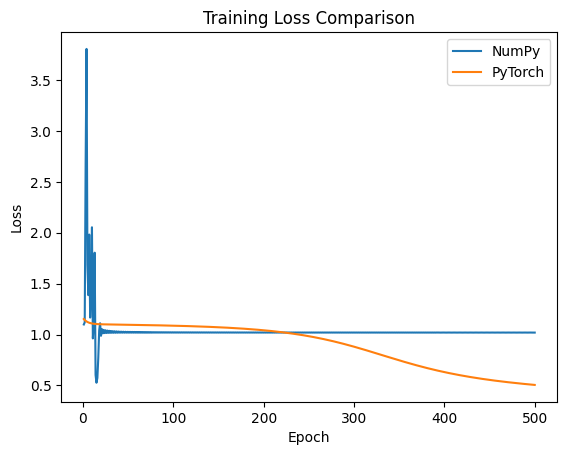

In [ ]:
plt.figure()
plt.plot(range(1, epochs_np+1), loss_hist_np, label='NumPy')
plt.plot(range(1, epochs_pt+1), loss_hist_pt, label='PyTorch')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

